## PART E — MINI PROJECT (Generative AI Insight)
## Mini Project: Synthetic Prompt Feature Generator (GAN)
## Task 10: Train GAN on Prompt Features

In [1]:
import numpy as np

# Each prompt has 4 features: length, keyword count, verb count, complexity
real_data = np.array([
    [10, 2, 3, 0.5],
    [12, 3, 4, 0.7],
    [8, 1, 2, 0.4],
    [15, 4, 5, 0.9],
    [9, 2, 2, 0.6],
])

batch_size = real_data.shape[0]
feature_dim = real_data.shape[1]
noise_dim = 5

In [2]:
class Generator:
    def forward(self, z):
        # Map noise to 4-feature prompt vector (dummy)
        batch_size = z.shape[0]
        return np.random.rand(batch_size, feature_dim)  # synthetic features

class Discriminator:
    def forward(self, x):
        # Output probability of being real
        batch_size = x.shape[0]
        return np.random.rand(batch_size, 1)

In [3]:
def bce_loss(pred, target):
    return -np.mean(target * np.log(pred + 1e-8) + (1 - target) * np.log(1 - pred + 1e-8))

# Initialize networks
G = Generator()
D = Discriminator()

# Generate noise
z = np.random.randn(batch_size, noise_dim)
fake_data = G.forward(z)

# Discriminator outputs
D_real = D.forward(real_data)
D_fake = D.forward(fake_data)

# Losses
D_loss = bce_loss(D_real, np.ones_like(D_real)) + bce_loss(D_fake, np.zeros_like(D_fake))
G_loss = bce_loss(D_fake, np.ones_like(D_fake))

print("D_loss:", D_loss)
print("G_loss:", G_loss)
print("Fake prompt features generated:\n", fake_data)

D_loss: 2.3517375557287243
G_loss: 1.103825554925821
Fake prompt features generated:
 [[0.57833282 0.41958299 0.97308893 0.2819395 ]
 [0.55552797 0.02300254 0.97140221 0.32434009]
 [0.40104015 0.05189964 0.01947719 0.12389389]
 [0.24572247 0.41847639 0.26209234 0.70539828]
 [0.14333319 0.19022108 0.89635924 0.72897616]]


## Task 11: Sample New Prompts

Fake prompt features:
 [[0.82352764 0.25088612 0.82014588 0.67874023]
 [0.78910164 0.72925043 0.95302248 0.79019296]
 [0.68731265 0.97643639 0.95243789 0.17719892]
 [0.54308121 0.80555633 0.67679586 0.10927593]
 [0.92922631 0.22871398 0.95310565 0.28807981]
 [0.31091222 0.32418765 0.43608232 0.05080464]
 [0.62513524 0.8195869  0.94922218 0.2999997 ]
 [0.77528469 0.47849776 0.22016397 0.8421333 ]
 [0.90114424 0.93314117 0.70829086 0.10883245]
 [0.85573269 0.08876058 0.78365662 0.95144154]]


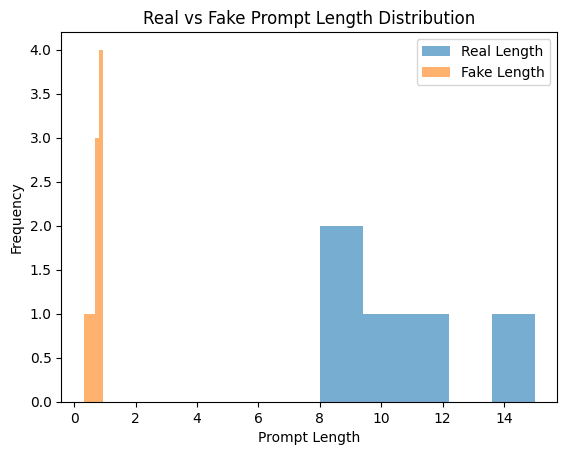

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Real data (prompt features)
real_data = np.array([
    [10, 2, 3, 0.5],
    [12, 3, 4, 0.7],
    [8, 1, 2, 0.4],
    [15, 4, 5, 0.9],
    [9, 2, 2, 0.6],
])

feature_dim = real_data.shape[1]
noise_dim = 5
num_samples = 10  # generate 10 new prompts

# Dummy Generator
class Generator:
    def forward(self, z):
        batch_size = z.shape[0]
        # Add small randomness to simulate diverse outputs
        return np.random.rand(batch_size, feature_dim)  

G = Generator()
z = np.random.randn(num_samples, noise_dim)
fake_data = G.forward(z)

print("Fake prompt features:\n", fake_data)

# Compare distributions (feature 0: Length)
plt.hist(real_data[:,0], bins=5, alpha=0.6, label='Real Length')
plt.hist(fake_data[:,0], bins=5, alpha=0.6, label='Fake Length')
plt.xlabel("Prompt Length")
plt.ylabel("Frequency")
plt.title("Real vs Fake Prompt Length Distribution")
plt.legend()
plt.show()